# Relationship Between AR, MA, ACF, and PACF

The relationship between **AR/MA models** and **ACF/PACF** is one of the most important concepts in ARIMA modeling because **ACF and PACF plots are used to determine the values of \(p\) and \(q\)**.

---

# The Big Picture

ARIMA has three parameters:

- **p** → Number of **AR** terms
- **d** → Degree of differencing
- **q** → Number of **MA** terms

The question is:

> **How do we find \(p\) and \(q\)?**

The answer is:

- **PACF helps identify \(p\) (AR order)**
- **ACF helps identify \(q\) (MA order)**

---

# Why does PACF identify AR?

Consider an AR(1) process:

$$
Y_t = 0.8Y_{t-1}+\epsilon_t
$$

The dependency chain is:

```text
Y(t-3) → Y(t-2) → Y(t-1) → Y(t)
```

Now let's see what happens.

### Correlation with Lag 1

```text
Y(t) ↔ Y(t−1)
```

Very strong.

---

### Correlation with Lag 2

```text
Y(t−2) → Y(t−1) → Y(t)
```

There **appears** to be a correlation.

But notice:

There is **no direct arrow** from \(Y_{t-2}\) to \(Y_t\).

The relationship exists only through \(Y_{t-1}\).

PACF removes the effect of \(Y_{t-1}\).

Therefore,

```text
PACF Lag 2 ≈ 0
```

---

## Hence

For **AR(1)**:

### ACF

```text
Lag1 ████████
Lag2 ██████
Lag3 ████
Lag4 ███
Lag5 ██
```

It gradually decreases (**tapers**).

### PACF

```text
Lag1 ████████
Lag2
Lag3
Lag4
```

It **cuts off** after Lag 1.

---

# AR(2)

Suppose

$$
Y_t
=
0.7Y_{t-1}
+
0.2Y_{t-2}
+
\epsilon_t
$$

Now there are **two direct influences**.

```text
Y(t−2) ─────►
             \
              ► Y(t)
             /
Y(t−1) ─────►
```

PACF detects both.

### PACF

```text
Lag1 ███████
Lag2 █████
Lag3
Lag4
```

Cuts off after Lag 2.

### ACF

Gradually tapers.

---

# Why does ACF identify MA?

Consider

$$
Y_t
=
\epsilon_t
+
0.6\epsilon_{t-1}
$$

The current value depends only on

```text
Today's error
Yesterday's error
```

---

## Lag 1

There is correlation because both observations share the same past error.

---

## Lag 2

There is **no shared error** anymore.

Hence

```text
Correlation ≈ 0
```

Therefore,

### ACF

```text
Lag1 ███████
Lag2
Lag3
Lag4
```

Cuts off after Lag 1.

### PACF

```text
Lag1 ███████
Lag2 █████
Lag3 ███
Lag4 ██
```

Gradually decreases.

---

# Why does this happen?

## AR Model

Observation influences observation.

```text
Y1 → Y2 → Y3 → Y4
```

Even if only Lag 1 is directly connected,

there is an indirect path

```text
Y1 → Y2 → Y3 → Y4
```

Therefore,

- **ACF** still finds correlation at higher lags.
- **PACF** removes these indirect effects.

---

## MA Model

Observation depends only on recent shocks.

```text
ε1 → Y1
 \
  → Y2
```

After one lag,

the common shock disappears.

Hence,

- **ACF** immediately becomes zero.
- **PACF** gradually decreases.

---

# Visual Intuition

## AR(1)

```text
Y1 → Y2 → Y3 → Y4 → Y5
```

### ACF

```text
1.00
0.80
0.64
0.51
0.41
```

Keeps decreasing.

### PACF

```text
1.00
0
0
0
```

Cuts off after Lag 1.

---

## MA(1)

```text
ε1 → Y1
 \
  → Y2
```

Only the first lag shares a common shock.

### ACF

```text
Lag1 ███████
Lag2
Lag3
```

Cuts off after Lag 1.

### PACF

```text
Lag1 ███████
Lag2 █████
Lag3 ███
Lag4 ██
```

Gradually decreases.

---

# ARMA Model

Suppose

$$
Y_t
=
0.7Y_{t-1}
+
\epsilon_t
+
0.4\epsilon_{t-1}
$$

Now we have

- Autoregression
- Moving Average

Both effects are present.

Hence,

- **ACF tapers**
- **PACF tapers**

Neither has a sharp cutoff.

---

# Summary Table

| Model | ACF | PACF | Interpretation |
|--------|-----|-------|---------------|
| **AR(1)** | Tapers | Cuts off after Lag 1 | Use PACF to identify \(p\) |
| **AR(2)** | Tapers | Cuts off after Lag 2 | PACF cutoff gives \(p\) |
| **MA(1)** | Cuts off after Lag 1 | Tapers | Use ACF to identify \(q\) |
| **MA(2)** | Cuts off after Lag 2 | Tapers | ACF cutoff gives \(q\) |
| **ARMA(p,q)** | Tapers | Tapers | Both AR and MA components present |

---

# Memory Trick

| Want to Find | Look At | Reason |
|---------------|----------|--------|
| **AR Order (\(p\))** | **PACF** | PACF measures only the **direct** effect of lagged observations. |
| **MA Order (\(q\))** | **ACF** | ACF captures the correlation introduced by shared past shocks. |

---

# Easy Way to Remember

- **AR → PACF → p**
- **MA → ACF → q**

A common mnemonic is:

- **P**ACF helps find **P** (AR order)
- **ACF** helps find **Q** (MA order)

---

# Key Takeaways

- **AR models** use **past observations**.
- **MA models** use **past forecast errors (shocks)**.
- **PACF** removes indirect effects and therefore identifies the **AR order (\(p\))**.
- **ACF** captures the effect of shared shocks and therefore identifies the **MA order (\(q\))**.
- **AR models:** ACF tapers, PACF cuts off.
- **MA models:** ACF cuts off, PACF tapers.
- **ARMA models:** Both ACF and PACF taper.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf
from pandas import read_csv
from datetime import datetime

In [2]:
data = pd.Series([10, 15, 20, 25, 30, 35, 40, 45, 50, 55])

# Generate lagged versions
lag_1 = data.shift(1)
lag_2 = data.shift(2)
lag_3 = data.shift(3)

In [5]:
lag_1,lag_2,lag_3

(0     NaN
 1    10.0
 2    15.0
 3    20.0
 4    25.0
 5    30.0
 6    35.0
 7    40.0
 8    45.0
 9    50.0
 dtype: float64,
 0     NaN
 1     NaN
 2    10.0
 3    15.0
 4    20.0
 5    25.0
 6    30.0
 7    35.0
 8    40.0
 9    45.0
 dtype: float64,
 0     NaN
 1     NaN
 2     NaN
 3    10.0
 4    15.0
 5    20.0
 6    25.0
 7    30.0
 8    35.0
 9    40.0
 dtype: float64)

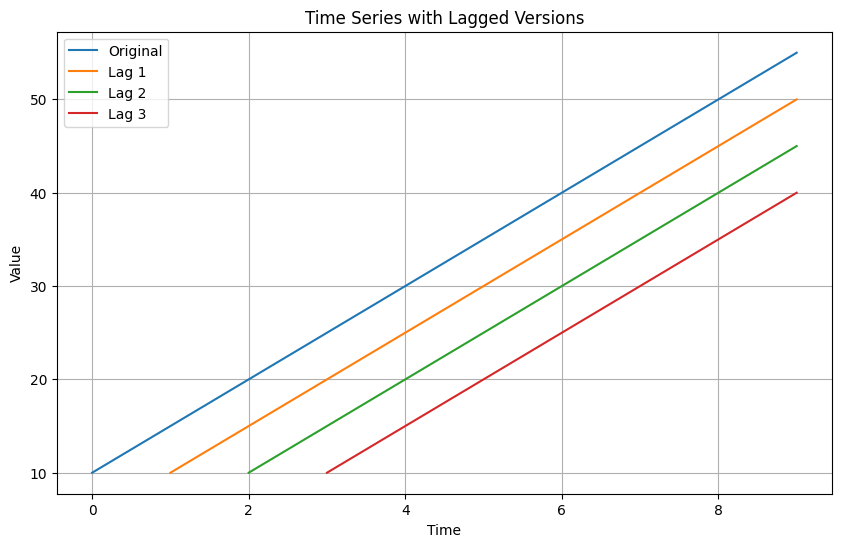

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original')
plt.plot(lag_1, label='Lag 1')
plt.plot(lag_2, label='Lag 2')
plt.plot(lag_3, label='Lag 3')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Time Series with Lagged Versions')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
def check_stationarity(series):

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

In [9]:
dateparse = lambda x: datetime.strptime('190'+x, '%Y-%m')

In [11]:
series_2 = read_csv('shampoo_sales.csv',  header=0, index_col=0)

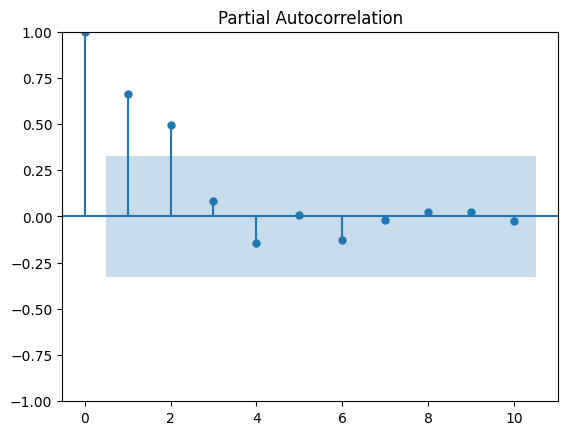

In [12]:
plot_pacf(series_2, lags=10)
plt.show()

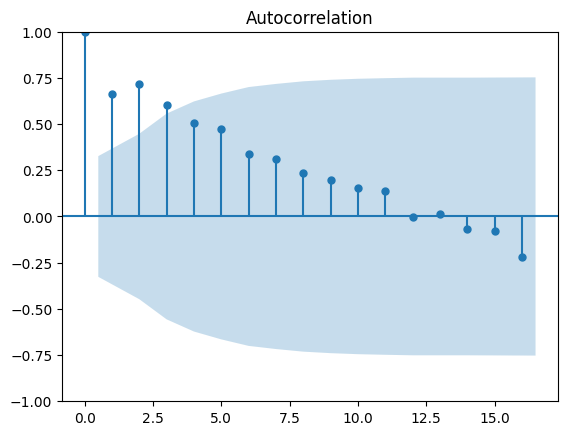

In [13]:
plot_acf(series_2)
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Parameters
np.random.seed(42)
n = 50  # Number of data points
mu = 0  # Mean of the series
theta = 0.7  # MA parameter

# Generate MA(1) time series data
errors = np.random.normal(loc=0, scale=1, size=n)
data = [mu + errors[0]]  # Initial value
for i in range(1, n):
    data.append(mu + theta * errors[i-1] + errors[i])

# Create pandas DataFrame
df = pd.DataFrame({'Time': pd.date_range(start='2024-01-01', periods=n, freq='D'),
                   'Data': data})

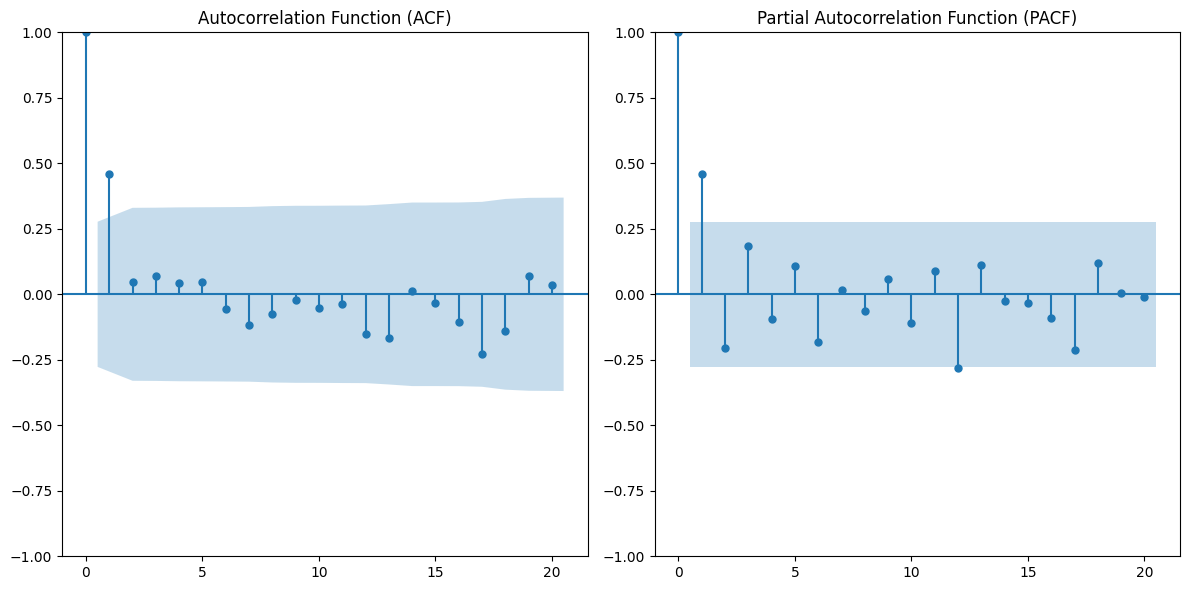

In [15]:
plt.figure(figsize=(12, 6))
plot_acf(df['Data'], lags=20, ax=plt.subplot(1, 2, 1))
plt.title('Autocorrelation Function (ACF)')
plot_pacf(df['Data'], lags=20, ax=plt.subplot(1, 2, 2))
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()